<a href="https://colab.research.google.com/github/Dineshok/trader-sentiment-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trader Performance vs Market Sentiment — Hyperliquid Analysis

**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed index) relates to
trader behavior and performance on Hyperliquid.

**Datasets:**
- Bitcoin Fear/Greed Index: 2,644 daily records
- Hyperliquid trader data: 211,224 trade rows across multiple accounts

**Structure:** Part A (Data Prep) → Part B (Analysis) → Part C (Strategy)

In [28]:
import pandas as pd
import numpy as np

# Load datasets
sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

# Basic info
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

# Preview
sentiment.head(), trades.head()

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [29]:
# Data quality check
print("=== SENTIMENT DATASET ===")
print(f"Rows: {sentiment.shape[0]}, Columns: {sentiment.shape[1]}")
print("\nMissing values per column:")
print(sentiment.isnull().sum())
print(f"\nDuplicate dates: {sentiment.duplicated(subset='date').sum()}")

print("\n=== TRADES DATASET ===")
print(f"Rows: {trades.shape[0]}, Columns: {trades.shape[1]}")
print("\nMissing values per column:")
print(trades.isnull().sum())
print(f"\nDuplicate rows: {trades.duplicated().sum()}")

=== SENTIMENT DATASET ===
Rows: 2644, Columns: 4

Missing values per column:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate dates: 0

=== TRADES DATASET ===
Rows: 211224, Columns: 16

Missing values per column:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows: 0


In [30]:
# Rename columns
trades = trades.rename(columns={
    'Account': 'account', 'Coin': 'symbol',
    'Execution Price': 'price', 'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd', 'Side': 'side',
    'Timestamp IST': 'time', 'Closed PnL': 'pnl'
})
sentiment = sentiment.rename(columns={'classification': 'sentiment'})

In [31]:
# Parse timestamps
trades['time'] = pd.to_datetime(trades['time'], dayfirst=True)
trades['date'] = trades['time'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [32]:
# Merge on date
merged = trades.merge(sentiment[['date', 'sentiment']], on='date', how='left')
print(merged[['date', 'account', 'pnl', 'sentiment']].head())

         date                                     account  pnl      sentiment
0  2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0  Extreme Greed
1  2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0  Extreme Greed
2  2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0  Extreme Greed
3  2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0  Extreme Greed
4  2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.0  Extreme Greed


In [33]:
# On Hyperliquid, Closed PnL = 0 means the row is an entry (position opened, nothing closed yet)
# Nonzero Closed PnL means a position was actually closed — that's when profit/loss is realized

print(f"Total rows: {len(merged)}")
print(f"Rows where PnL = 0 (entries/opens): {(merged['pnl'] == 0).sum()}")
print(f"Rows where PnL != 0 (closed trades): {(merged['pnl'] != 0).sum()}")

# Split into two dataframes — use each for the right purpose
all_trades = merged.copy()                      # use for: trade frequency, trade size, long/short ratio
closed = merged[merged['pnl'] != 0].copy()      # use for: PnL, win rate, drawdown

print(f"\nall_trades shape: {all_trades.shape}")
print(f"closed shape: {closed.shape}")

Total rows: 211224
Rows where PnL = 0 (entries/opens): 106816
Rows where PnL != 0 (closed trades): 104408

all_trades shape: (211224, 18)
closed shape: (104408, 18)


**Key finding:** 106,816 out of 211,224 rows are position entries (Closed PnL = 0).
These have no realized profit/loss yet. All performance analysis (PnL, win rate) will use
only the 104,408 closed rows. Behavioral analysis (trade frequency, size) uses all rows.

In [34]:
# Win = trade closed with positive PnL
closed['win'] = closed['pnl'] > 0

# Performance by sentiment (using closed trades only)
pnl_by_sentiment   = closed.groupby('sentiment')['pnl'].mean().reset_index()
win_by_sentiment   = closed.groupby('sentiment')['win'].mean().reset_index()

# Reorder for logical display (Fear -> Greed)
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

pnl_by_sentiment  = pnl_by_sentiment.set_index('sentiment').reindex(sentiment_order).reset_index()
win_by_sentiment  = win_by_sentiment.set_index('sentiment').reindex(sentiment_order).reset_index()

print("=== Avg Closed PnL by Sentiment ===")
print(pnl_by_sentiment)

print("\n=== Win Rate by Sentiment ===")
win_by_sentiment['win_pct'] = (win_by_sentiment['win'] * 100).round(1)
print(win_by_sentiment[['sentiment', 'win_pct']])

=== Avg Closed PnL by Sentiment ===
       sentiment         pnl
0   Extreme Fear   71.027316
1           Fear  112.625988
2        Neutral   71.199993
3          Greed   85.403927
4  Extreme Greed  130.205309

=== Win Rate by Sentiment ===
       sentiment  win_pct
0   Extreme Fear     76.2
1           Fear     87.3
2        Neutral     82.4
3          Greed     76.9
4  Extreme Greed     89.2


**Insight 1: Performance vs Sentiment**
- Avg closed PnL is highest on Extreme Greed days ($130) and lowest on Extreme Fear ($71).
- Win rates are high across all conditions (76–89%) — these are active, experienced traders.
- The PnL gap is driven by trade size/risk-taking, not win frequency.
- Key takeaway: sentiment affects HOW MUCH traders make per trade, not WHETHER they win.

In [35]:
# Behavioral metrics — use all_trades (includes entries, captures full activity)
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Trade frequency per sentiment
trade_freq = all_trades.groupby('sentiment').size().reindex(sentiment_order)

# Avg trade size per sentiment
trade_size = all_trades.groupby('sentiment')['size_usd'].mean().reindex(sentiment_order)

# Long/short ratio per sentiment
side_counts = all_trades.groupby(['sentiment', 'side']).size().unstack(fill_value=0)
side_counts['long_pct'] = (side_counts.get('BUY', 0) /
                           (side_counts.get('BUY', 0) + side_counts.get('SELL', 0)) * 100)
side_counts = side_counts.reindex(sentiment_order)

print("=== Trade Frequency by Sentiment ===")
print(trade_freq)

print("\n=== Avg Trade Size (USD) by Sentiment ===")
print(trade_size.round(2))

print("\n=== Long % by Sentiment ===")
print(side_counts['long_pct'].round(1))

=== Trade Frequency by Sentiment ===
sentiment
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
dtype: int64

=== Avg Trade Size (USD) by Sentiment ===
sentiment
Extreme Fear     5349.73
Fear             7816.11
Neutral          4782.73
Greed            5736.88
Extreme Greed    3112.25
Name: size_usd, dtype: float64

=== Long % by Sentiment ===
sentiment
Extreme Fear     51.1
Fear             49.0
Neutral          50.3
Greed            48.9
Extreme Greed    44.9
Name: long_pct, dtype: float64


**Insight 2: Trader Behavior by Sentiment**
- Highest trade frequency is during Fear (61,837 trades) — not Greed as expected.
- Largest avg trade size is also during Fear ($7,816) — traders are taking bigger bets on dips.
- Extreme Greed has the smallest trade size ($3,112) — possibly profit-taking in smaller clips.
- Long/short ratio is nearly flat across all sentiments (45–51%) — these traders don't shift
  directional bias much based on sentiment. They trade both sides regardless.
- Key takeaway: Fear drives more activity and bigger size, not less — opposite of retail intuition.

/tmp/ipykernel_750/1210567398.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(sentiment_order, rotation=25, ha='right')
/tmp/ipykernel_750/1210567398.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(sentiment_order, rotation=25, ha='right')
/tmp/ipykernel_750/1210567398.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(sentiment_order, rotation=25, ha='right')
/tmp/ipykernel_750/1210567398.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(sentiment_order, rotation=25, ha='right')


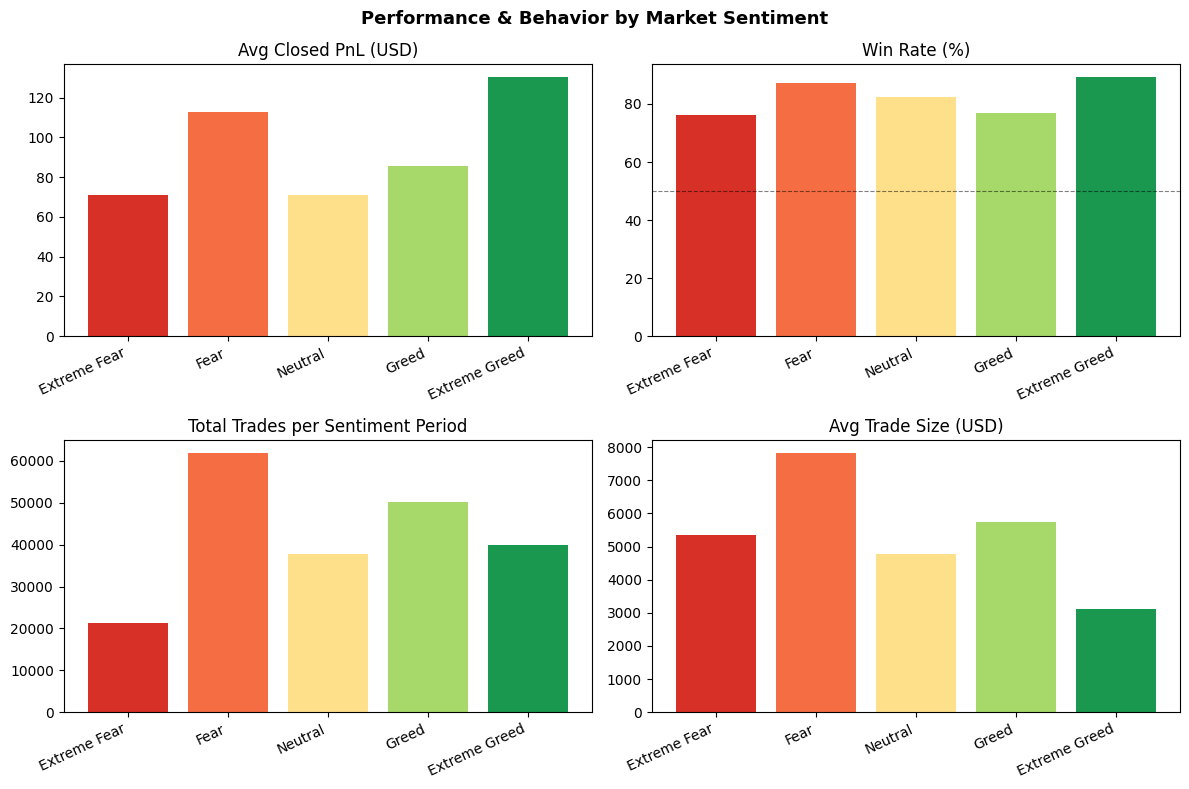

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Performance & Behavior by Market Sentiment", fontsize=13, fontweight='bold')

colors = ['#d73027', '#f46d43', '#fee08b', '#a6d96a', '#1a9850']

# Chart 1: Avg Closed PnL
axes[0,0].bar(sentiment_order, pnl_by_sentiment['pnl'], color=colors)
axes[0,0].set_title("Avg Closed PnL (USD)")
axes[0,0].set_xticklabels(sentiment_order, rotation=25, ha='right')

# Chart 2: Win Rate
axes[0,1].bar(sentiment_order, win_by_sentiment['win_pct'], color=colors)
axes[0,1].axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0,1].set_title("Win Rate (%)")
axes[0,1].set_xticklabels(sentiment_order, rotation=25, ha='right')

# Chart 3: Trade Frequency
axes[1,0].bar(sentiment_order, trade_freq.values, color=colors)
axes[1,0].set_title("Total Trades per Sentiment Period")
axes[1,0].set_xticklabels(sentiment_order, rotation=25, ha='right')

# Chart 4: Avg Trade Size
axes[1,1].bar(sentiment_order, trade_size.values, color=colors)
axes[1,1].set_title("Avg Trade Size (USD)")
axes[1,1].set_xticklabels(sentiment_order, rotation=25, ha='right')

plt.tight_layout()
plt.show()

In [37]:
# Build a profile for each trader account
account_stats = closed.groupby('account').agg(
    total_pnl    = ('pnl', 'sum'),
    trade_count  = ('pnl', 'count'),
    win_rate     = ('win', 'mean'),
    avg_pnl      = ('pnl', 'mean'),
    pnl_std      = ('pnl', 'std')   # how consistent they are
).reset_index()

account_stats['pnl_std'] = account_stats['pnl_std'].fillna(0)

# Segment 1: Frequent vs Infrequent (split at median)
median_trades = account_stats['trade_count'].median()
account_stats['freq_segment'] = account_stats['trade_count'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

# Segment 2: Consistent vs Inconsistent (split by std of PnL)
median_std = account_stats['pnl_std'].median()
account_stats['consistency'] = account_stats['pnl_std'].apply(
    lambda x: 'Consistent' if x < median_std else 'Inconsistent'
)

print(f"Median trades per account: {median_trades}")
print(f"Median PnL std: {median_std:.2f}")

print("\n=== Frequent vs Infrequent ===")
print(account_stats.groupby('freq_segment')[['total_pnl','win_rate','avg_pnl','trade_count']].mean().round(2))

print("\n=== Consistent vs Inconsistent ===")
print(account_stats.groupby('consistency')[['total_pnl','win_rate','avg_pnl']].mean().round(2))

Median trades per account: 1749.5
Median PnL std: 766.03

=== Frequent vs Infrequent ===
              total_pnl  win_rate  avg_pnl  trade_count
freq_segment                                           
Frequent      412360.24      0.83    74.37      5855.06
Infrequent    231199.69      0.87   421.54       670.44

=== Consistent vs Inconsistent ===
              total_pnl  win_rate  avg_pnl
consistency                               
Consistent    138397.58      0.85    68.75
Inconsistent  505162.35      0.85   427.16


**Insight 3: Trader Segmentation**

Frequent vs Infrequent:
- Frequent traders grind (5,855 trades avg, $74 avg PnL per trade)
- Infrequent traders wait for conviction (670 trades avg, $421 avg PnL per trade)
- Win rate is similar (83% vs 87%) — both are skilled, just different styles

Consistent vs Inconsistent:
- "Inconsistent" (high PnL variance) traders earn far more ($427 avg) than consistent ones ($68)
- Same win rate (85%) — inconsistent traders aren't losing more often, they're sizing up bigger
- Consistency here means small safe trades, not better performance

=== Avg PnL: Frequent vs Infrequent across Sentiments ===
sentiment     Extreme Fear    Fear  Neutral   Greed  Extreme Greed
freq_segment                                                      
Frequent             42.77   68.38    66.60   43.50         120.17
Infrequent          212.46  404.20   129.02  485.47         276.88


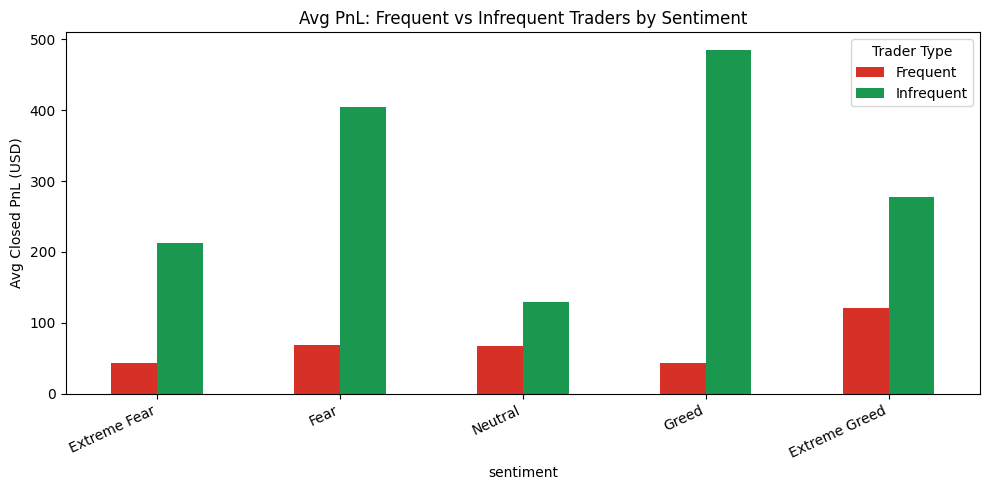

In [38]:
# Merge segment labels back into closed trades
closed_seg = closed.merge(
    account_stats[['account', 'freq_segment', 'consistency']],
    on='account', how='left'
)

# Avg PnL by freq_segment and sentiment
seg_pnl = closed_seg.groupby(['freq_segment', 'sentiment'])['pnl'].mean().unstack()
seg_pnl = seg_pnl.reindex(columns=sentiment_order)

print("=== Avg PnL: Frequent vs Infrequent across Sentiments ===")
print(seg_pnl.round(2))

# Plot
seg_pnl.T.plot(kind='bar', figsize=(10, 5), color=['#d73027', '#1a9850'])
plt.title("Avg PnL: Frequent vs Infrequent Traders by Sentiment")
plt.xticks(rotation=25, ha='right')
plt.ylabel("Avg Closed PnL (USD)")
plt.legend(title="Trader Type")
plt.tight_layout()
plt.show()

**Insight 4: Segment Performance across Sentiments**
- Infrequent traders outperform frequent traders in every single sentiment regime
- The biggest gap is on Greed days: infrequent ($485) vs frequent ($43) — 11x difference
- Frequent traders' best day is Extreme Greed ($120) — still far below infrequent traders
- Infrequent traders peak on Greed ($485) and Fear ($404) — they capitalize on both extremes
- Frequent traders are relatively flat across sentiments — grinding regardless of conditions

## Part C — Strategy Recommendations

**Rule 1: If you are an infrequent/conviction trader — be most aggressive on Greed and Fear days**
Infrequent traders earn $485 avg on Greed days and $404 on Fear days — their two best regimes.
These are high-volatility, high-conviction moments. Size up on those days, not on Neutral days
($129 avg) where the edge is smallest.

**Rule 2: If you are a frequent/grinding trader — shift to Extreme Greed for best results**
Frequent traders are flat across most sentiments ($43–68) but jump to $120 on Extreme Greed days.
This is the one regime where momentum is strong enough that even high-frequency grinding captures
meaningful PnL per trade. Reduce trade frequency on Greed/Extreme Fear days where their edge
drops to $43 — not worth the transaction fees.

In [40]:
import os
os.makedirs("charts", exist_ok=True)

# Save the 4-chart figure
fig.savefig("charts/sentiment_analysis.png", dpi=150, bbox_inches='tight')

# Save the segmentation chart
plt.figure()  # this saves whatever the last plot was
plt.savefig("charts/segmentation_analysis.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>